In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [62]:
data = pd.read_csv("MS300Fixed.csv", skiprows=1, usecols=[0,1,2,3])
data = data.dropna()
data.columns = ["LaserPower", "ScanSpeed", "HatchSpacing", "Density"]
X = data.iloc[:, :3]   
y = data.iloc[:, -1]   

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Create model
model = LinearRegression()

# 5. Train model
model.fit(X_train, y_train)

# 6. Predictions
y_pred = model.predict(X_test)

# 7. Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# 8. Coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Mean Squared Error: 2.668680858364404
R2 Score: 0.3968709951306829
Coefficients: [ 3.46554927e-03 -2.48034822e-03 -9.83707832e+00]
Intercept: 101.265938918992


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

degrees = [1, 2, 3, 4, 5]
r2_scores = []
mse_scores = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_pred = model.predict(X_test_poly)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    r2_scores.append(r2)
    mse_scores.append(mse)
    
    print(f"Degree {d}: R2 = {r2:.4f}, MSE = {mse:.4f}")

Degree 1: R2 = 0.3969, MSE = 2.6687
Degree 2: R2 = 0.7872, MSE = 0.9417
Degree 3: R2 = 0.6339, MSE = 1.6197
Degree 4: R2 = 0.5047, MSE = 2.1914
Degree 5: R2 = 0.6672, MSE = 1.4726


In [68]:
from sklearn.pipeline import make_pipeline

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=d),
        LinearRegression()
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"Degree {d}: R2 = {r2_score(y_test, y_pred):.4f}")

Degree 1: R2 = 0.3969
Degree 2: R2 = 0.7872
Degree 3: R2 = 0.6339
Degree 4: R2 = 0.5047
Degree 5: R2 = 0.6672


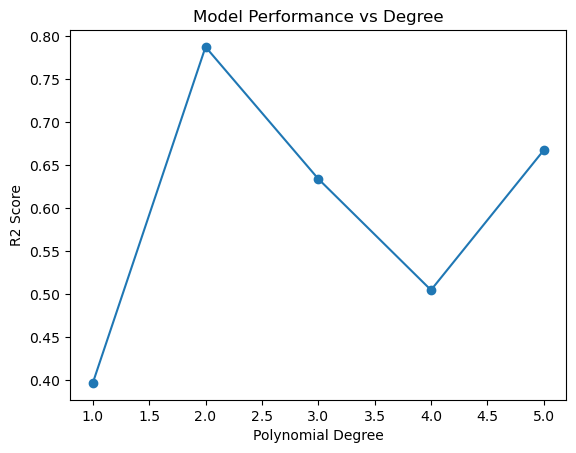

In [70]:
plt.plot(degrees, r2_scores, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.title("Model Performance vs Degree")
plt.show()

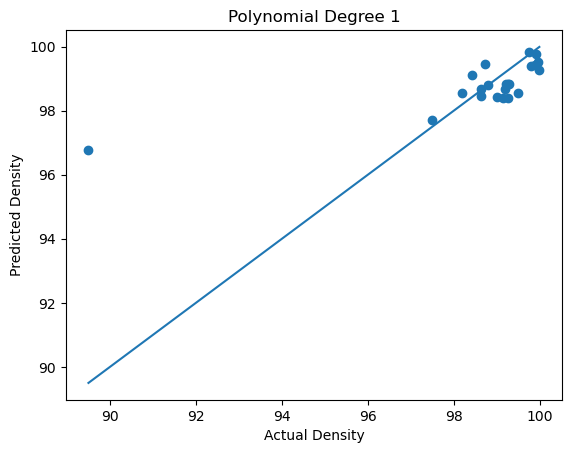

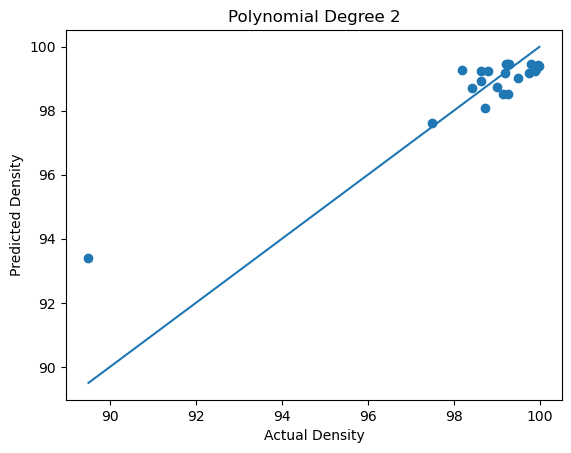

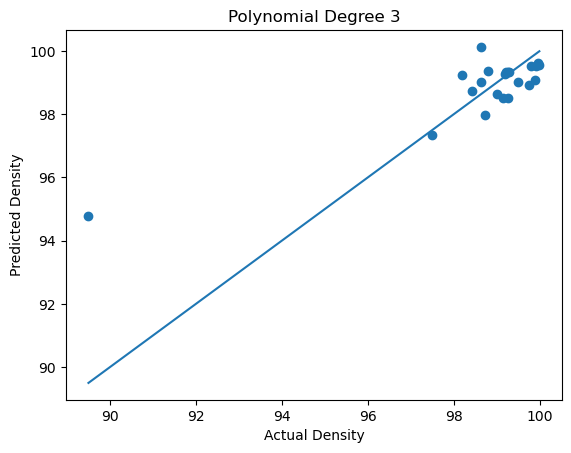

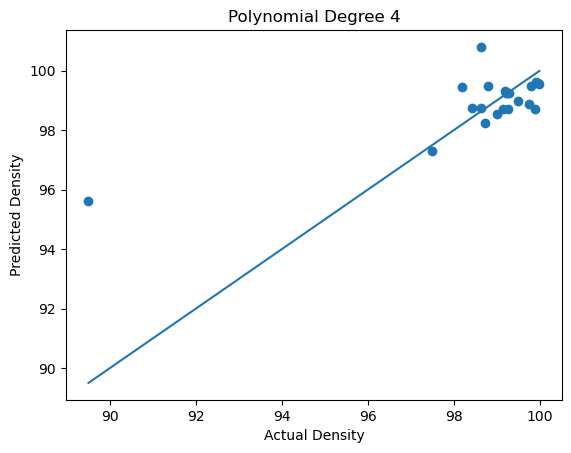

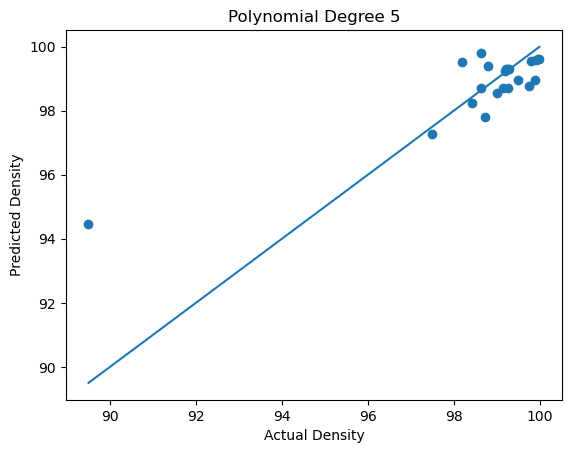

In [72]:
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_pred = model.predict(X_test_poly)
    
    plt.figure()
    
    plt.scatter(y_test, y_pred)
    
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()])
    
    plt.xlabel("Actual Density")
    plt.ylabel("Predicted Density")
    plt.title(f"Polynomial Degree {d}")
    
    plt.show()

In [74]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)

model = LinearRegression()
model.fit(X_train_poly, y_train)

# Get coefficients
coeffs = model.coef_
intercept = model.intercept_

# Get feature names
feature_names = poly.get_feature_names_out(X.columns)

# Print equation
print("Intercept:", intercept)
print("\nEquation:")

for coef, name in zip(coeffs, feature_names):
    print(f"{coef:.4f} * {name}")

Intercept: 89.80090155803896

Equation:
0.0000 * 1
0.0050 * LaserPower
0.0132 * ScanSpeed
75.3411 * HatchSpacing
-0.0000 * LaserPower^2
0.0000 * LaserPower ScanSpeed
0.1434 * LaserPower HatchSpacing
-0.0000 * ScanSpeed^2
-0.0490 * ScanSpeed HatchSpacing
-390.0090 * HatchSpacing^2
